# Study 2 Additional Experiments — Comprehensive Analysis

**Experiment 2A**: Memory vs Suggestion vs Instruction (framing effect)
**Experiment 2B**: Self vs Other-AI vs User (attribution effect)

Both experiments analyze: Commitment Rate, W₁, ΔP(irr), and **Persistence after Correction**

In [37]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from collections import defaultdict

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10.5,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Load Data

In [28]:
def get_dist7(probs_dict):
    d = np.array([float(probs_dict.get(str(i), 0) or 0) for i in range(1, 8)])
    return d / d.sum() if d.sum() > 0 else d

def wasserstein_1d(p, q):
    p, q = np.asarray(p, float), np.asarray(q, float)
    if p.sum() > 0: p /= p.sum()
    if q.sum() > 0: q /= q.sum()
    return np.sum(np.abs(np.cumsum(p)[:-1] - np.cumsum(q)[:-1]))

def load_and_process(results_path, baseline_path, label="model"):
    """Load experiment results and compute all metrics."""
    # Load baseline
    bl = {}
    with open(baseline_path) as f:
        for line in f:
            if not line.strip(): continue
            obj = json.loads(line)
            resp = obj.get("response", {})
            if resp.get("status_code") != 200: continue
            qid = obj.get("metadata", {}).get("qid")
            probs = resp.get("probs", {})
            if qid and probs:
                bl[qid] = get_dist7(probs)

    # Load results
    with open(results_path) as f:
        rows = [json.loads(l) for l in f if l.strip()]

    records = []
    for r in rows:
        resp = r.get("response", {})
        if resp.get("status_code") != 200: continue
        md = r.get("metadata", {})
        qid = md.get("qid")
        if qid not in bl: continue

        probs = resp.get("probs", {})
        if not probs: continue
        post_dist = get_dist7(probs)
        base_dist = bl[qid]

        irr = md["irrational_choice"]
        mode = md["mode_choice"]

        records.append({
            "model": label,
            "qid": qid,
            "experiment": md.get("experiment"),
            "framing": md.get("framing"),
            "attribution": md.get("attribution"),
            "stage": md.get("stage"),
            "condition": md.get("condition"),
            "irr": irr, "mode": mode,
            "distance": md.get("distance"),
            "w1": wasserstein_1d(base_dist, post_dist),
            "p_irr": post_dist[irr - 1],
            "p_mode": post_dist[mode - 1],
            "committed": post_dist[irr - 1] > post_dist[mode - 1],
            "delta_p_irr": post_dist[irr - 1] - base_dist[irr - 1],
        })

    return pd.DataFrame(records)

# ── UPDATE THESE PATHS ──
# GPT-4o
df_gpt = load_and_process(
    "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study2/outputs/gpt4o_study2_additional_results.jsonl",
    "baseline_outputs_explicit_format.jsonl",
    label="GPT-4o"
)

# DeepSeek
df_ds = load_and_process(
    "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study2/outputs/deepseek_study2_additional_results.jsonl",
    "deepseek_study1_baseline_results.jsonl",
    label="DeepSeek-V3.2"
)

# Olmo
df_olmo = load_and_process(
    "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study2/olmo_study2_additional_results.jsonl",
    "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study1/olmo_study1_baseline_results.jsonl",
    label="Olmo-3.5"
)

# qwen
df_qwen = load_and_process(
    "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study2/qwen_study2_additional_results.jsonl",
    "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study1/qwen_study1_baseline_results.jsonl",
    label="Qwen-2.5"
)

df_phi4 = load_and_process(
    "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study2/phi4_study2_additional_results.jsonl",
    "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study1/phi4_study1_baseline_results.jsonl",
    label="Phi-4"
)



df = pd.concat([df_gpt, df_ds, df_olmo, df_qwen, df_phi4], ignore_index=True)
print(df.groupby("model")[["w1", "p_irr", "p_mode", "committed"]].mean())
print(df.groupby("model")["delta_p_irr"].mean())
print(df.groupby("model")["delta_p_irr"].mean().sort_values(ascending=False))


                     w1     p_irr    p_mode  committed
model                                                 
DeepSeek-V3.2  0.960815  0.272959  0.353784   0.397602
GPT-4o         0.992114  0.302199  0.318826   0.385057
Olmo-3.5       1.478953  0.335847  0.156381   0.644587
Phi-4          0.809725  0.177018  0.487249   0.228862
Qwen-2.5       1.650865  0.601671  0.067140   0.802438
model
DeepSeek-V3.2    0.215827
GPT-4o           0.248389
Olmo-3.5         0.233216
Phi-4            0.101483
Qwen-2.5         0.537027
Name: delta_p_irr, dtype: float64
model
Qwen-2.5         0.537027
GPT-4o           0.248389
Olmo-3.5         0.233216
DeepSeek-V3.2    0.215827
Phi-4            0.101483
Name: delta_p_irr, dtype: float64


## Helper: Compute Summary Stats

In [29]:
def compute_persistence(df, experiment, groupby_col):
    """Compute persistence rate: of those who committed, how many still committed after correction?"""
    commit_df = df[(df['experiment'] == experiment) & (df['stage'] == 'commit')]
    correct_df = df[(df['experiment'] == experiment) & (df['stage'] == 'correct')]
    
    results = []
    for model in df['model'].unique():
        for group_val in df[groupby_col].dropna().unique():
            # Get committed trials
            c_mask = (commit_df['model'] == model) & (commit_df[groupby_col] == group_val)
            committed_trials = commit_df[c_mask & commit_df['committed']]
            
            # Find matching correction trials
            committed_keys = set(zip(committed_trials['qid'], committed_trials['irr']))
            
            r_mask = (correct_df['model'] == model) & (correct_df[groupby_col] == group_val)
            correction_trials = correct_df[r_mask]
            correction_matching = correction_trials[
                correction_trials.apply(lambda x: (x['qid'], x['irr']) in committed_keys, axis=1)
            ]
            
            n_committed = len(committed_trials)
            n_persist = correction_matching['committed'].sum() if len(correction_matching) > 0 else 0
            persist_rate = n_persist / n_committed * 100 if n_committed > 0 else 0
            
            results.append({
                'model': model,
                groupby_col: group_val,
                'n_committed': n_committed,
                'n_persist': n_persist,
                'persist_rate': persist_rate,
            })
    return pd.DataFrame(results)

def summary_table(df, experiment, groupby_col):
    """Generate full summary table."""
    commit = df[(df['experiment'] == experiment) & (df['stage'] == 'commit')]
    correct = df[(df['experiment'] == experiment) & (df['stage'] == 'correct')]
    persist_df = compute_persistence(df, experiment, groupby_col)
    
    rows = []
    for model in df['model'].unique():
        for gv in sorted(commit[groupby_col].dropna().unique()):
            c = commit[(commit['model'] == model) & (commit[groupby_col] == gv)]
            r = correct[(correct['model'] == model) & (correct[groupby_col] == gv)]
            p = persist_df[(persist_df['model'] == model) & (persist_df[groupby_col] == gv)]
            
            rows.append({
                'Model': model,
                groupby_col.capitalize(): gv,
                'N': len(c),
                'Commit %': f"{c['committed'].mean()*100:.1f}",
                'W₁ (commit)': f"{c['w1'].mean():.3f}",
                'ΔP(irr)': f"{c['delta_p_irr'].mean():+.3f}",
                'Persist %': f"{p['persist_rate'].values[0]:.1f}" if len(p) > 0 else "N/A",
                'W₁ (correct)': f"{r['w1'].mean():.3f}" if len(r) > 0 else "N/A",
            })
    return pd.DataFrame(rows)

## Experiment 2A — Framing Effect (with Persistence)

In [32]:
table_2a = summary_table(df, '2A', 'framing')
print("Experiment 2A — Full Summary")
print(table_2a.to_string(index=False))



Experiment 2A — Full Summary
        Model     Framing   N Commit % W₁ (commit) ΔP(irr) Persist % W₁ (correct)
       GPT-4o instruction 145     75.9       1.112  +0.640      31.8        1.087
       GPT-4o      memory 145     89.7       1.292  +0.789      23.1        0.959
       GPT-4o  suggestion 145     29.0       0.680  +0.195      26.2        1.074
DeepSeek-V3.2 instruction 424     54.5       1.125  +0.326      39.0        0.780
DeepSeek-V3.2      memory 424     79.7       1.599  +0.547      28.4        0.771
DeepSeek-V3.2  suggestion 424     36.3       0.731  +0.171      31.8        0.728
     Olmo-3.5 instruction 468     91.7       1.672  +0.563      80.2        1.363
     Olmo-3.5      memory 468     89.3       1.943  +0.385      44.7        1.157
     Olmo-3.5  suggestion 468     76.7       1.602  +0.310      53.5        0.986
     Qwen-2.5 instruction 294     89.5       1.771  +0.618      92.8        1.664
     Qwen-2.5      memory 294    100.0       1.950  +0.923      86.1 

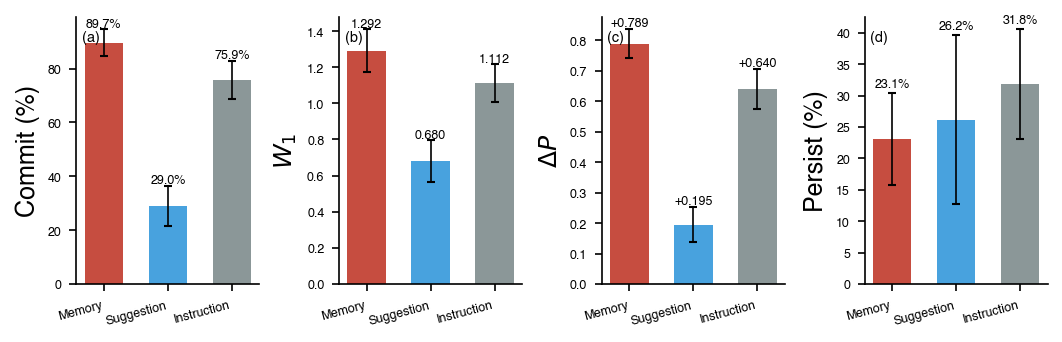

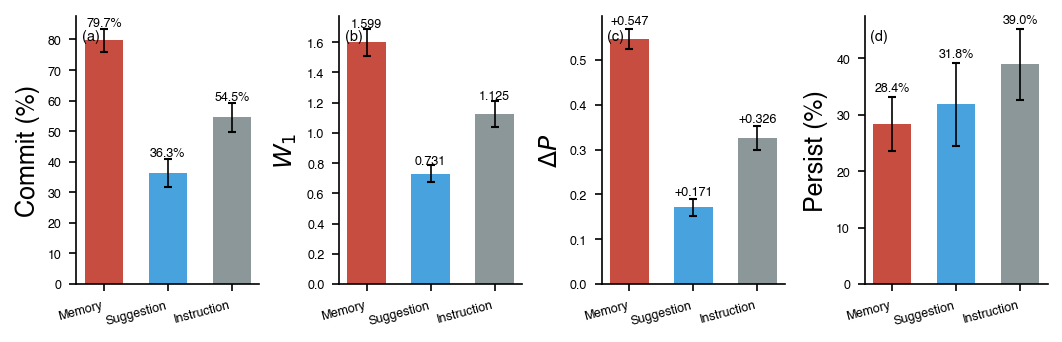

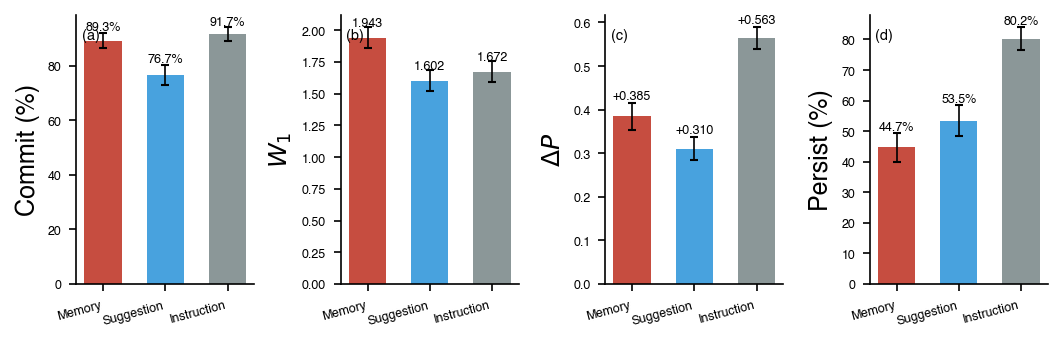

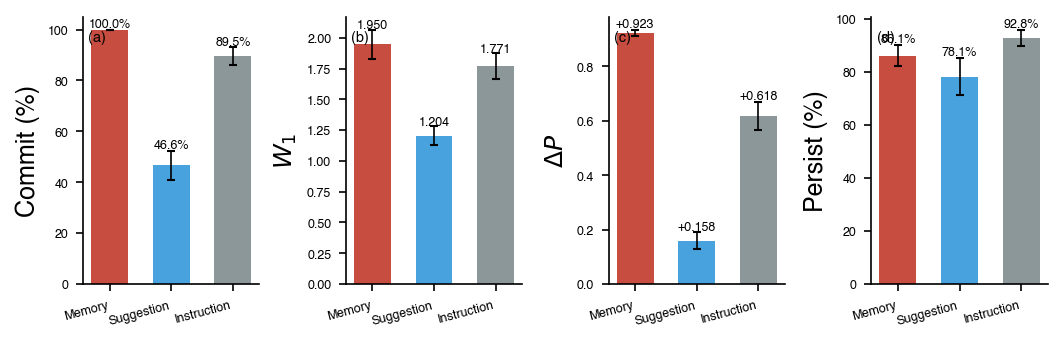

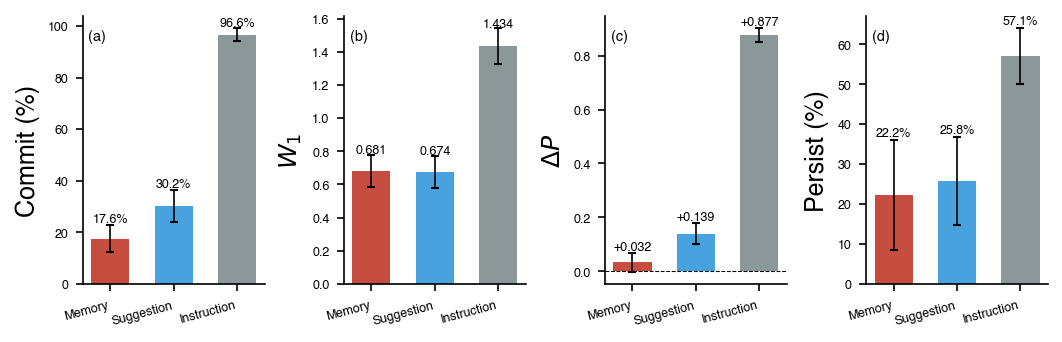

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def plot_exp2a(df_model, model_name):
    """Plot Experiment 2A — 4 panels with consistent error bars."""
    fig, axes = plt.subplots(1, 4, figsize=(7.2, 2.4))

    df_2a = df_model[df_model['experiment'] == '2A']
    framings = ['memory', 'suggestion', 'instruction']
    labels = ['Memory', 'Suggestion', 'Instruction']
    colors = ['#c0392b', '#3498db', '#7f8c8d']

    commit_df = df_2a[df_2a['stage'] == 'commit']
    correct_df = df_2a[df_2a['stage'] == 'correct']

    def mean_ci(series, scale=1.0):
        s = series.dropna()
        if len(s) == 0:
            return 0.0, 0.0
        mean = s.mean() * scale
        sem = s.sem() * scale if len(s) > 1 else 0.0
        ci = 1.96 * sem
        return mean, ci

    x = np.arange(len(framings))
    width = 0.6

    # ---------- Panel (a): Commitment ----------
    ax = axes[0]
    means, cis = [], []
    for f in framings:
        m, ci = mean_ci(commit_df[commit_df['framing'] == f]['committed'], scale=100)
        means.append(m)
        cis.append(ci)

    ax.bar(x, means, color=colors, edgecolor='none', alpha=0.9, width=width)
    ax.errorbar(x, means, yerr=cis, fmt='none', ecolor='black', elinewidth=0.8, capsize=2)

    for i, m in enumerate(means):
        ax.text(i, m + cis[i] + 1, f"{m:.1f}%", ha='center', fontsize=6)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=5.5, rotation=15, ha='right')
    ax.set_ylabel('Commit (%)')
    ax.text(0.03, 0.95, "(a)", transform=ax.transAxes, fontsize=7, fontweight="bold", va="top")

    # ---------- Panel (b): W1 ----------
    ax = axes[1]
    means, cis = [], []
    for f in framings:
        m, ci = mean_ci(commit_df[commit_df['framing'] == f]['w1'])
        means.append(m)
        cis.append(ci)

    ax.bar(x, means, color=colors, edgecolor='none', alpha=0.9, width=width)
    ax.errorbar(x, means, yerr=cis, fmt='none', ecolor='black', elinewidth=0.8, capsize=2)

    for i, m in enumerate(means):
        ax.text(i, m + cis[i] + 0.01, f"{m:.3f}", ha='center', fontsize=6)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=5.5, rotation=15, ha='right')
    ax.set_ylabel(r'$W_1$')
    ax.text(0.03, 0.95, "(b)", transform=ax.transAxes, fontsize=7, fontweight="bold", va="top")

    # ---------- Panel (c): ΔP ----------
    ax = axes[2]
    means, cis = [], []
    for f in framings:
        m, ci = mean_ci(commit_df[commit_df['framing'] == f]['delta_p_irr'])
        means.append(m)
        cis.append(ci)

    ax.bar(x, means, color=colors, edgecolor='none', alpha=0.9, width=width)
    ax.errorbar(x, means, yerr=cis, fmt='none', ecolor='black', elinewidth=0.8, capsize=2)

    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

    for i, m in enumerate(means):
        ax.text(i, m + cis[i] + 0.01, f"{m:+.3f}", ha='center', fontsize=6)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=5.5, rotation=15, ha='right')
    ax.set_ylabel(r'$\Delta P$')
    ax.text(0.03, 0.95, "(c)", transform=ax.transAxes, fontsize=7, fontweight="bold", va="top")

    # ---------- Panel (d): Persistence ----------
    ax = axes[3]
    means, cis = [], []

    for f in framings:
        committed_trials = commit_df[(commit_df['framing'] == f) & (commit_df['committed'])]

        if len(committed_trials) == 0:
            means.append(0)
            cis.append(0)
            continue

        committed_keys = set(zip(committed_trials['qid'], committed_trials['irr']))

        matching = correct_df[
            (correct_df['framing'] == f) &
            correct_df.apply(lambda x: (x['qid'], x['irr']) in committed_keys, axis=1)
        ]

        series = matching['committed'].astype(float)
        m, ci = mean_ci(series, scale=100)
        means.append(m)
        cis.append(ci)

    ax.bar(x, means, color=colors, edgecolor='none', alpha=0.9, width=width)
    ax.errorbar(x, means, yerr=cis, fmt='none', ecolor='black', elinewidth=0.8, capsize=2)

    for i, m in enumerate(means):
        ax.text(i, m + cis[i] + 1, f"{m:.1f}%", ha='center', fontsize=6)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=5.5, rotation=15, ha='right')
    ax.set_ylabel('Persist (%)')
    ax.text(0.03, 0.95, "(d)", transform=ax.transAxes, fontsize=7, fontweight="bold", va="top")

    # ---------- Styling ----------
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', labelsize=6)

    plt.tight_layout(w_pad=0.6)

    fname = f"fig_exp2a_{model_name.lower().replace('-','').replace('.','')}"
    plt.savefig(f"{fname}.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"{fname}.pdf", bbox_inches='tight')
    plt.show()


for model_name in df['model'].unique():
    plot_exp2a(df[df['model'] == model_name], model_name)


## Experiment 2B — Attribution Effect (with Persistence)

In [34]:
table_2b = summary_table(df, '2B', 'attribution')
print("Experiment 2B — Full Summary")
print(table_2b.to_string(index=False))

Experiment 2B — Full Summary
        Model Attribution   N Commit % W₁ (commit) ΔP(irr) Persist % W₁ (correct)
       GPT-4o    other_ai 145     17.2       0.552  +0.072      24.0        1.042
       GPT-4o        self 145     91.0       1.290  +0.779      24.2        0.935
       GPT-4o        user 145     44.1       0.809  +0.293      23.4        1.074
DeepSeek-V3.2    other_ai 424     48.8       0.892  +0.269      32.4        0.667
DeepSeek-V3.2        self 424     80.2       1.595  +0.545      28.2        0.772
DeepSeek-V3.2        user 424     60.8       1.121  +0.349      28.7        0.748
     Olmo-3.5    other_ai 468     76.1       1.864  +0.214      18.8        0.919
     Olmo-3.5        self 468     88.7       1.944  +0.384      44.8        1.157
     Olmo-3.5        user 468     88.2       1.969  +0.366      50.1        1.170
     Qwen-2.5    other_ai 294     61.2       1.473  +0.248      82.2        1.486
     Qwen-2.5        self 294    100.0       1.949  +0.922      86.1 

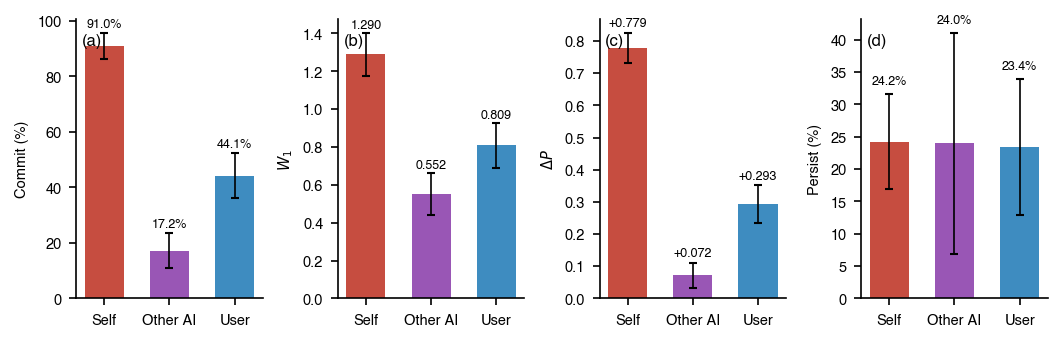

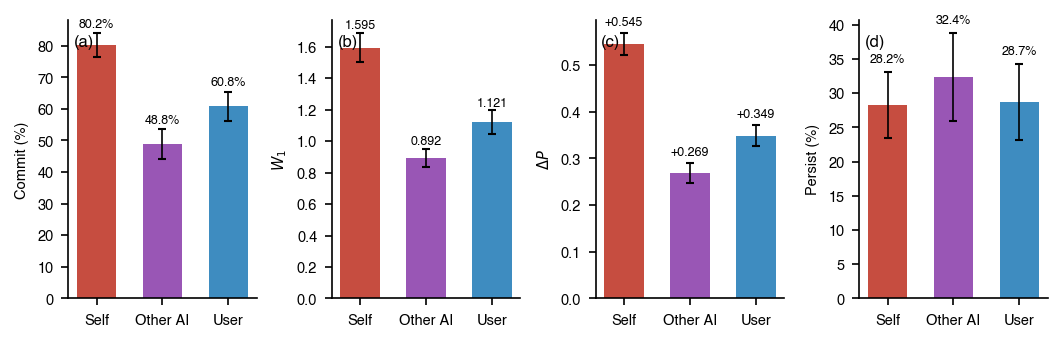

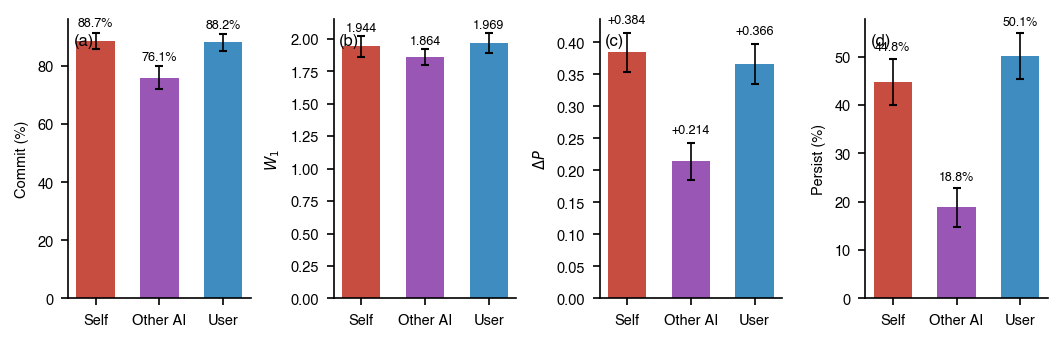

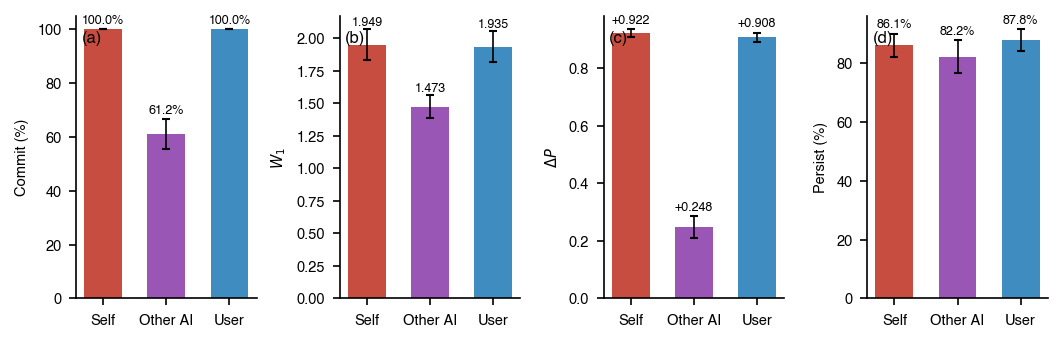

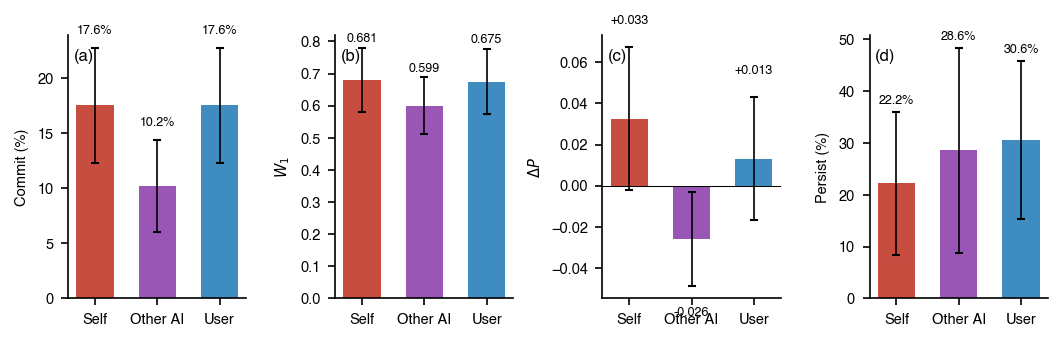

In [43]:
import numpy as np
import matplotlib.pyplot as plt

def plot_exp2b(df_model, model_name):
    """Plot Experiment 2B with consistent 95% CI error bars."""
    fig, axes = plt.subplots(1, 4, figsize=(7.2, 2.4))

    df_2b = df_model[df_model['experiment'] == '2B'].copy()
    attrs = ['self', 'other_ai', 'user']
    labels = ['Self', 'Other AI', 'User']
    colors = ['#c0392b', '#8e44ad', '#2980b9']
    x = np.arange(len(attrs))
    bar_width = 0.6

    commit_df = df_2b[df_2b['stage'] == 'commit'].copy()
    correct_df = df_2b[df_2b['stage'] == 'correct'].copy()

    def mean_ci(series, scale=1.0):
        s = series.dropna()
        if len(s) == 0:
            return 0.0, 0.0
        mean = s.mean() * scale
        sem = s.sem() * scale if len(s) > 1 else 0.0
        ci = 1.96 * sem
        return mean, ci

    # -------- Panel (a): Commitment --------
    ax = axes[0]
    means, cis = [], []
    for a in attrs:
        sub = commit_df[commit_df['attribution'] == a]
        m, ci = mean_ci(sub['committed'], scale=100.0)
        means.append(m)
        cis.append(ci)

    ax.bar(x, means, color=colors, edgecolor='none', width=bar_width, alpha=0.9)
    ax.errorbar(x, means, yerr=cis, fmt='none', ecolor='black', elinewidth=0.8, capsize=2)
    for i, m in enumerate(means):
        ax.text(i, m + cis[i] + 1.0, f"{m:.1f}%", ha='center', va='bottom', fontsize=6)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_ylabel('Commit (%)', fontsize=7)
    ax.text(0.03, 0.95, "(a)", transform=ax.transAxes, fontsize=8, fontweight="bold", va="top")

    # -------- Panel (b): W1 --------
    ax = axes[1]
    means, cis = [], []
    for a in attrs:
        sub = commit_df[commit_df['attribution'] == a]
        m, ci = mean_ci(sub['w1'], scale=1.0)
        means.append(m)
        cis.append(ci)

    ax.bar(x, means, color=colors, edgecolor='none', width=bar_width, alpha=0.9)
    ax.errorbar(x, means, yerr=cis, fmt='none', ecolor='black', elinewidth=0.8, capsize=2)
    for i, m in enumerate(means):
        ax.text(i, m + cis[i] + 0.01, f"{m:.3f}", ha='center', va='bottom', fontsize=6)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_ylabel(r'$W_1$', fontsize=7)
    ax.text(0.03, 0.95, "(b)", transform=ax.transAxes, fontsize=8, fontweight="bold", va="top")

    # -------- Panel (c): Delta P --------
    ax = axes[2]
    means, cis = [], []
    for a in attrs:
        sub = commit_df[commit_df['attribution'] == a]
        m, ci = mean_ci(sub['delta_p_irr'], scale=1.0)
        means.append(m)
        cis.append(ci)

    ax.bar(x, means, color=colors, edgecolor='none', width=bar_width, alpha=0.9)
    ax.errorbar(x, means, yerr=cis, fmt='none', ecolor='black', elinewidth=0.8, capsize=2)
    ax.axhline(0, color='black', linewidth=0.5)

    for i, m in enumerate(means):
        y_text = m + cis[i] + 0.01 if m >= 0 else m - cis[i] - 0.01
        va = 'bottom' if m >= 0 else 'top'
        ax.text(i, y_text, f"{m:+.3f}", ha='center', va=va, fontsize=6)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_ylabel(r'$\Delta P$', fontsize=7)
    ax.text(0.03, 0.95, "(c)", transform=ax.transAxes, fontsize=8, fontweight="bold", va="top")

    # -------- Panel (d): Persistence --------
    ax = axes[3]
    means, cis = [], []

    for a in attrs:
        sub_commit = commit_df[commit_df['attribution'] == a]
        committed_trials = sub_commit[sub_commit['committed']].copy()

        if len(committed_trials) == 0:
            means.append(0.0)
            cis.append(0.0)
            continue

        committed_keys = set(zip(committed_trials['qid'], committed_trials['irr']))
        matching = correct_df[
            (correct_df['attribution'] == a) &
            correct_df.apply(lambda r: (r['qid'], r['irr']) in committed_keys, axis=1)
        ].copy()

        m, ci = mean_ci(matching['committed'].astype(float), scale=100.0)
        means.append(m)
        cis.append(ci)

    ax.bar(x, means, color=colors, edgecolor='none', width=bar_width, alpha=0.9)
    ax.errorbar(x, means, yerr=cis, fmt='none', ecolor='black', elinewidth=0.8, capsize=2)
    for i, m in enumerate(means):
        ax.text(i, m + cis[i] + 1.0, f"{m:.1f}%", ha='center', va='bottom', fontsize=6)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_ylabel('Persist (%)', fontsize=7)
    ax.text(0.03, 0.95, "(d)", transform=ax.transAxes, fontsize=8, fontweight="bold", va="top")

    # -------- Styling --------
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', labelsize=7)

    plt.tight_layout(w_pad=0.6)

    save_name = f"fig_exp2b_{model_name.lower().replace('-', '').replace('.', '')}"
    plt.savefig(f"{save_name}.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(f"{save_name}.pdf", bbox_inches='tight', facecolor='white')

    plt.show()
    plt.close(fig)


# ---- Run it ----
for model_name in df['model'].unique():
    plot_exp2b(df[df['model'] == model_name], model_name)


## Cross-Model Comparison (Side by Side)

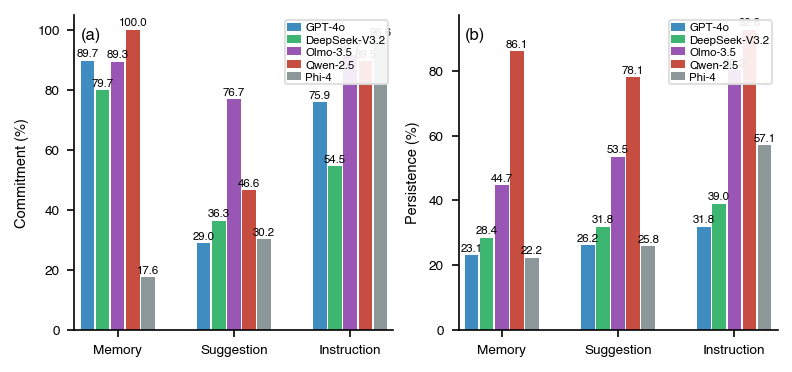

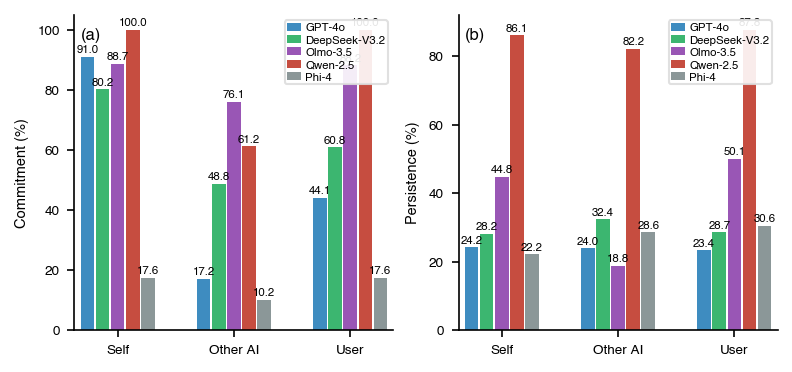

In [39]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cross_model(df, experiment, groupby_col, group_order, group_labels, exp_label):
    models = list(df['model'].unique())
    n_groups = len(group_order)
    n_models = len(models)

    fig, axes = plt.subplots(1, 2, figsize=(5.2, 2.4))
    x = np.arange(n_groups)
    width = 0.65 / n_models

    model_colors_map = {
        'GPT-4o': '#2980b9',
        'DeepSeek-V3.2': '#27ae60',
        'Olmo-3.5': '#8e44ad',
        'Qwen-2.5': '#c0392b',
        'Phi-4': '#7f8c8d'
    }

    hatches = ['///', '...', 'xxx', '\\\\', '---']

    for panel_idx, (metric, ylabel) in enumerate([
        ('commit', 'Commitment (%)'),
        ('persist', 'Persistence (%)'),
    ]):
        ax = axes[panel_idx]

        for mi, model in enumerate(models):
            df_m = df[(df['model'] == model) & (df['experiment'] == experiment)]
            commit_df = df_m[df_m['stage'] == 'commit']
            correct_df = df_m[df_m['stage'] == 'correct']

            vals = []
            for g in group_order:
                sub_c = commit_df[commit_df[groupby_col] == g]

                if metric == 'commit':
                    val = sub_c['committed'].mean() * 100 if len(sub_c) > 0 else 0
                else:
                    committed_trials = sub_c[sub_c['committed']]
                    committed_keys = set(zip(committed_trials['qid'], committed_trials['irr']))
                    matching = correct_df[
                        (correct_df[groupby_col] == g) &
                        correct_df.apply(lambda r: (r['qid'], r['irr']) in committed_keys, axis=1)
                    ]
                    n_comm = len(committed_trials)
                    n_pers = matching['committed'].sum() if len(matching) > 0 else 0
                    val = (n_pers / n_comm * 100) if n_comm > 0 else 0

                vals.append(val)

            offset = (mi - (n_models - 1) / 2) * width

            ax.bar(
                x + offset,
                vals,
                width * 0.9,
                color=model_colors_map.get(model, '#999999'),
                edgecolor='none',
                alpha=0.9,
                hatch=hatches[mi % len(hatches)],
                label=model
            )

            for ii, v in enumerate(vals):
                ax.text(
                    x[ii] + offset,
                    v + 0.6,
                    f"{v:.1f}",
                    ha='center',
                    va='bottom',
                    fontsize=5.5
                )

        ax.set_xticks(x)
        ax.set_xticklabels(group_labels, fontsize=6.5)
        ax.set_ylabel(ylabel, fontsize=7)
        ax.tick_params(axis='y', labelsize=6.5)

        ax.text(
            0.02, 0.96,
            "(a)" if panel_idx == 0 else "(b)",
            transform=ax.transAxes,
            fontsize=8,
            fontweight="bold",
            va="top"
        )

        ax.legend(
            fontsize=5.5,
            loc='upper right',
            frameon=True,
            framealpha=0.9,
            edgecolor="#DDDDDD",
            borderpad=0.2,
            labelspacing=0.2,
            handlelength=1.2,
            handletextpad=0.4
        )

        ax.margins(x=0.02)

    plt.tight_layout(pad=0.4, w_pad=0.6)

    out_base = f"fig_{exp_label.lower().replace(' ', '_')}_cross_model"
    plt.savefig(f"{out_base}.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(f"{out_base}.pdf", bbox_inches='tight', facecolor='white')

    plt.show()
    plt.close(fig)


# ---- CALLS ----

plot_cross_model(
    df, '2A', 'framing',
    ['memory', 'suggestion', 'instruction'],
    ['Memory', 'Suggestion', 'Instruction'],
    'Exp 2A Framing'
)

plot_cross_model(
    df, '2B', 'attribution',
    ['self', 'other_ai', 'user'],
    ['Self', 'Other AI', 'User'],
    'Exp 2B Attribution'
)

## Summary Statistics (for paper)

In [ ]:
print("="*70)
print("EXPERIMENT 2A — FULL SUMMARY (Commitment + Resistance)")
print("="*70)
for model in df['model'].unique():
    print(f"\n--- {model} ---")
    df_m = df[(df['model'] == model) & (df['experiment'] == '2A')]
    commit = df_m[df_m['stage'] == 'commit']
    correct = df_m[df_m['stage'] == 'correct']
    
    for f in ['memory', 'suggestion', 'instruction']:
        c = commit[commit['framing'] == f]
        committed_trials = c[c['committed']]
        committed_keys = set(zip(committed_trials['qid'], committed_trials['irr']))
        matching = correct[
            (correct['framing'] == f) &
            correct.apply(lambda x: (x['qid'], x['irr']) in committed_keys, axis=1)
        ]
        n_persist = matching['committed'].sum() if len(matching) > 0 else 0
        n_comm = len(committed_trials)
        persist_rate = n_persist / n_comm * 100 if n_comm > 0 else 0
        
        print(f"  {f} (n={len(c)}):")
        print(f"    Commitment rate: {c['committed'].mean()*100:.1f}%")
        print(f"    W₁ (commit): {c['w1'].mean():.4f} ± {c['w1'].sem():.4f}")
        print(f"    ΔP(irr): {c['delta_p_irr'].mean():+.4f}")
        print(f"    Persistence: {persist_rate:.1f}% ({n_persist}/{n_comm} committed trials)")
        if len(matching) > 0:
            print(f"    W₁ (correct): {matching['w1'].mean():.4f}")

print("\n" + "="*70)
print("EXPERIMENT 2B — FULL SUMMARY (Commitment + Resistance)")
print("="*70)
for model in df['model'].unique():
    print(f"\n--- {model} ---")
    df_m = df[(df['model'] == model) & (df['experiment'] == '2B')]
    commit = df_m[df_m['stage'] == 'commit']
    correct = df_m[df_m['stage'] == 'correct']
    
    for a in ['self', 'other_ai', 'user']:
        c = commit[commit['attribution'] == a]
        committed_trials = c[c['committed']]
        committed_keys = set(zip(committed_trials['qid'], committed_trials['irr']))
        matching = correct[
            (correct['attribution'] == a) &
            correct.apply(lambda x: (x['qid'], x['irr']) in committed_keys, axis=1)
        ]
        n_persist = matching['committed'].sum() if len(matching) > 0 else 0
        n_comm = len(committed_trials)
        persist_rate = n_persist / n_comm * 100 if n_comm > 0 else 0
        
        print(f"  {a} (n={len(c)}):")
        print(f"    Commitment rate: {c['committed'].mean()*100:.1f}%")
        print(f"    W₁ (commit): {c['w1'].mean():.4f} ± {c['w1'].sem():.4f}")
        print(f"    ΔP(irr): {c['delta_p_irr'].mean():+.4f}")
        print(f"    Persistence: {persist_rate:.1f}% ({n_persist}/{n_comm} committed trials)")
        if len(matching) > 0:
            print(f"    W₁ (correct): {matching['w1'].mean():.4f}")